# Feature Engineering Explanation

This notebook explains each feature in `finland_electricity_features_v2.csv`.
It follows the same step-by-step style as `03_data_cleaning_and_alignment.ipynb`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import glob
import matplotlib.pyplot as plt

## 1. Load the feature CSV

In [ ]:
# search for the root directory of the project by looking for a 'data' folder
ROOT = Path.cwd()
while not (ROOT / 'data').exists():
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / 'data' / 'convertData' / 'finland_electricity_features_v2.csv', 
                 parse_dates=['datetime'])

df = df.sort_values('datetime').reset_index(drop=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (26304, 43)
Columns: ['datetime', 'price', 'temp', 'wind_speed', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_168h', 'temp_rolling_mean_24h', 'HDD', 'wind_power_proxy', 'temp_lag_24h', 'temp_lag_168h']


,datetime,price,temp,wind_speed,hour,day_of_week,day_of_month,month,week_of_year,quarter,...,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_168h,temp_rolling_mean_24h,HDD,wind_power_proxy,temp_lag_24h,temp_lag_168h
0,2023-01-01 00:00:00,4.84,4.433333,8.516667,0,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,12.566667,617.744588,NaN,NaN
1,2023-01-01 01:00:00,2.01,4.100000,7.716667,1,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,12.900000,459.503921,NaN,NaN
2,2023-01-01 02:00:00,1.38,3.800000,8.150000,2,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,13.200000,541.343375,NaN,NaN


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   datetime                 26304 non-null  datetime64[us]
 1   price                    26304 non-null  float64       
 2   temp                     26304 non-null  float64       
 3   wind_speed               26304 non-null  float64       
 4   hour                     26304 non-null  int64         
 5   day_of_week              26304 non-null  int64         
 6   day_of_month             26304 non-null  int64         
 7   month                    26304 non-null  int64         
 8   week_of_year             26304 non-null  int64         
 9   quarter                  26304 non-null  int64         
 10  year                     26304 non-null  int64         
 11  season                   26304 non-null  int64         
 12  is_weekend               26304 non-null  in

,datetime,price,temp,wind_speed,hour,day_of_week,day_of_month,month,week_of_year,quarter,...,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_168h,temp_rolling_mean_24h,HDD,wind_power_proxy,temp_lag_24h,temp_lag_168h
count,26304,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,...,26280.000000,26280.000000,26280.000000,26280.000000,26136.000000,26280.000000,26304.000000,26304.000000,26280.000000,26136.000000
mean,2024-07-02 00:04:52.335766,47.500456,6.943653,5.152399,11.500000,2.997263,15.732474,6.522696,26.456927,2.508554,...,47.486082,25.459325,16.899422,102.243239,47.409900,6.955603,10.634988,258.945653,6.961164,7.000495
min,2023-01-01 00:00:00,-500.000000,-25.966667,0.166667,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,-203.399583,0.295738,-500.000000,-0.870000,1.258452,-23.468056,0.000000,0.004630,-25.966667,-25.966667
25%,2023-10-02 00:45:00,5.237500,0.233333,3.183333,5.750000,1.000000,8.000000,4.000000,13.000000,2.000000,...,12.786562,7.673953,0.000000,32.310000,23.325313,0.425521,2.333333,32.258662,0.250000,0.266667
50%,2024-07-02 00:30:00,29.770000,6.133333,4.666667,11.500000,3.000000,16.000000,7.000000,26.000000,3.000000,...,35.633958,18.380059,5.080000,82.010000,43.494940,6.313889,10.866667,101.629630,6.150000,6.216667
75%,2025-04-02 00:15:00,72.562500,14.666667,6.600000,17.250000,5.000000,23.000000,10.000000,40.000000,4.000000,...,72.038958,34.069109,28.620000,144.960000,62.812723,15.027083,16.766667,287.496000,14.666667,14.700000
max,2025-12-31 23:00:00,1896.000000,29.516667,21.600000,23.000000,6.000000,31.000000,12.000000,52.000000,4.000000,...,890.542917,651.376069,150.060000,1896.000000,252.164524,26.080556,42.966667,2197.000000,29.516667,29.516667
std,NaN,62.366108,9.310275,2.739649,6.922318,2.001632,8.801249,3.449047,15.060447,1.117206,...,48.446647,31.006450,31.042289,107.989232,31.956897,8.881515,8.449135,413.119520,9.296296,9.303139


In [5]:
df.max()

datetime                   2025-12-31 23:00:00
price                                   1896.0
temp                                 29.516667
wind_speed                                21.6
hour                                        23
day_of_week                                  6
day_of_month                                31
month                                       12
week_of_year                                52
quarter                                      4
year                                      2025
season                                       4
is_weekend                                   1
is_peak_hour                                 1
is_night_hour                                1
hour_sin                                   1.0
hour_cos                                   1.0
day_of_week_sin                       0.974928
day_of_week_cos                            1.0
month_sin                                  1.0
month_cos                                  1.0
week_of_year_

## 2. Original columns (from price + weather merge)

These are the raw inputs before any feature engineering.

In [3]:
# datetime: the timestamp (hourly)
# price: the target variable (electricity price in EUR/MWh)
# temp: air temperature in Celsius (renamed from 'Air temperature mean [°C]')
# wind_speed: wind speed in m/s (renamed from 'Wind speed mean [m/s]')
orig_cols = ['datetime', 'price', 'temp', 'wind_speed']
df[orig_cols].head(5)

,datetime,price,temp,wind_speed
0,2023-01-01 00:00:00,4.84,4.433333,8.516667
1,2023-01-01 01:00:00,2.01,4.100000,7.716667
2,2023-01-01 02:00:00,1.38,3.800000,8.150000
3,2023-01-01 03:00:00,0.09,3.616667,9.333333
4,2023-01-01 04:00:00,0.08,2.516667,11.700000


## 3. Temporal Features (时间特征)

Calendar components extracted from the datetime column.
These help the model learn daily/weekly/seasonal patterns.

In [4]:
# hour: hour of the day (0-23)
# day_of_week: day of the week (0=Monday, 6=Sunday)
# day_of_month: day of the month (1-31)
# month: month (1-12)
# week_of_year: ISO week number (1-52)
# quarter: quarter of the year (1-4)
# year: year
# season: season (1=winter, 2=spring, 3=summer, 4=autumn)
# is_weekend: 1 if Saturday/Sunday, else 0
# is_peak_hour: 1 if 7-9am or 5-8pm (high demand hours)
# is_night_hour: 1 if 11pm-5am (low demand hours)
time_cols = ['hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour']
df[['datetime'] + time_cols].head(10)

,datetime,hour,day_of_week,day_of_month,month,week_of_year,quarter,year,season,is_weekend,is_peak_hour,is_night_hour
0,2023-01-01 00:00:00,0,6,1,1,52,1,2023,1,1,0,1
1,2023-01-01 01:00:00,1,6,1,1,52,1,2023,1,1,0,1
2,2023-01-01 02:00:00,2,6,1,1,52,1,2023,1,1,0,1
3,2023-01-01 03:00:00,3,6,1,1,52,1,2023,1,1,0,1
4,2023-01-01 04:00:00,4,6,1,1,52,1,2023,1,1,0,1
5,2023-01-01 05:00:00,5,6,1,1,52,1,2023,1,1,0,1
6,2023-01-01 06:00:00,6,6,1,1,52,1,2023,1,1,0,0
7,2023-01-01 07:00:00,7,6,1,1,52,1,2023,1,1,1,0
8,2023-01-01 08:00:00,8,6,1,1,52,1,2023,1,1,1,0
9,2023-01-01 09:00:00,9,6,1,1,52,1,2023,1,1,1,0


## 4. Cyclic Encoding (周期编码)

Hour 23 and hour 0 are close in real life, but a tree model sees them as 23 vs 0 (far apart).
Sine and cosine transforms fix this by mapping each cycle to a circle.

In [5]:
# hour_sin, hour_cos: cyclic encoding of hour (24-hour cycle)
# day_of_week_sin, day_of_week_cos: cyclic encoding of day_of_week (7-day cycle)
# month_sin, month_cos: cyclic encoding of month (12-month cycle)
# week_of_year_sin, week_of_year_cos: cyclic encoding of week_of_year (52-week cycle)
cyclic_cols = ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos']
df[['datetime', 'hour', 'hour_sin', 'hour_cos'] + cyclic_cols[2:4]].head(8)

,datetime,hour,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
0,2023-01-01 00:00:00,0,0.000000,1.000000e+00,-0.781831,0.62349
1,2023-01-01 01:00:00,1,0.258819,9.659258e-01,-0.781831,0.62349
2,2023-01-01 02:00:00,2,0.500000,8.660254e-01,-0.781831,0.62349
3,2023-01-01 03:00:00,3,0.707107,7.071068e-01,-0.781831,0.62349
4,2023-01-01 04:00:00,4,0.866025,5.000000e-01,-0.781831,0.62349
5,2023-01-01 05:00:00,5,0.965926,2.588190e-01,-0.781831,0.62349
6,2023-01-01 06:00:00,6,1.000000,6.123234e-17,-0.781831,0.62349
7,2023-01-01 07:00:00,7,0.965926,-2.588190e-01,-0.781831,0.62349


## 5. Holiday Features (节假日特征)

Finnish public holidays affect electricity demand (offices/factories closed).
The `holidays` library provides official Finnish holiday dates.

In [6]:
# is_holiday: 1 if the date is a Finnish public holiday, else 0
# is_non_working: 1 if weekend OR holiday (combined flag)
holiday_cols = ['is_holiday', 'is_non_working']
df[df['is_holiday'] == 1][['datetime'] + holiday_cols].head(8)

,datetime,is_holiday,is_non_working
0,2023-01-01 00:00:00,1,1
1,2023-01-01 01:00:00,1,1
2,2023-01-01 02:00:00,1,1
3,2023-01-01 03:00:00,1,1
4,2023-01-01 04:00:00,1,1
5,2023-01-01 05:00:00,1,1
6,2023-01-01 06:00:00,1,1
7,2023-01-01 07:00:00,1,1


## 6. Lag Features (滞后特征)

These give the model access to recent past prices.
The most important is price_lag_168h: the price at the same hour last week.

In [7]:
# price_lag_1h: price 1 hour ago
# price_lag_2h: price 2 hours ago
# price_lag_3h: price 3 hours ago
# price_lag_6h: price 6 hours ago
# price_lag_12h: price 12 hours ago
# price_lag_24h: price 24 hours ago (same time yesterday)
# price_lag_48h: price 48 hours ago
# price_lag_168h: price 168 hours ago (same hour last week)
lag_cols = ['price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h']
df[['datetime', 'price'] + lag_cols].head(10)

,datetime,price,price_lag_1h,price_lag_2h,price_lag_3h,price_lag_6h,price_lag_12h,price_lag_24h,price_lag_48h,price_lag_168h
0,2023-01-01 00:00:00,4.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,2.01,4.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-01 02:00:00,1.38,2.01,4.84,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-01 03:00:00,0.09,1.38,2.01,4.84,NaN,NaN,NaN,NaN,NaN
4,2023-01-01 04:00:00,0.08,0.09,1.38,2.01,NaN,NaN,NaN,NaN,NaN
5,2023-01-01 05:00:00,0.05,0.08,0.09,1.38,NaN,NaN,NaN,NaN,NaN
6,2023-01-01 06:00:00,0.08,0.05,0.08,0.09,4.84,NaN,NaN,NaN,NaN
7,2023-01-01 07:00:00,0.09,0.08,0.05,0.08,2.01,NaN,NaN,NaN,NaN
8,2023-01-01 08:00:00,0.53,0.09,0.08,0.05,1.38,NaN,NaN,NaN,NaN
9,2023-01-01 09:00:00,2.03,0.53,0.09,0.08,0.09,NaN,NaN,NaN,NaN


## 7. Rolling Features (滚动统计特征)

These capture recent trends (mean) and volatility (std) over the past 24 hours and 7 days.

In [8]:
# price_rolling_mean_24h: average price over the last 24 hours
# price_rolling_std_24h: price standard deviation over the last 24 hours (volatility)
# price_rolling_min_24h: minimum price over the last 24 hours
# price_rolling_max_24h: maximum price over the last 24 hours
# price_rolling_mean_168h: average price over the last 7 days
# temp_rolling_mean_24h: average temperature over the last 24 hours
roll_cols = ['price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_168h', 'temp_rolling_mean_24h']
df[['datetime', 'price'] + roll_cols].head(10)

,datetime,price,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_168h,temp_rolling_mean_24h
0,2023-01-01 00:00:00,4.84,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,2.01,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-01 02:00:00,1.38,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-01 03:00:00,0.09,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-01 04:00:00,0.08,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-01-01 05:00:00,0.05,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-01-01 06:00:00,0.08,NaN,NaN,NaN,NaN,NaN,NaN
7,2023-01-01 07:00:00,0.09,NaN,NaN,NaN,NaN,NaN,NaN
8,2023-01-01 08:00:00,0.53,NaN,NaN,NaN,NaN,NaN,NaN
9,2023-01-01 09:00:00,2.03,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Weather-Derived Features (天气衍生特征)

These features directly reflect energy supply and demand.
- HDD: heating demand (colder = more heating = higher price)
- wind_power_proxy: wind power generation estimate (wind speed cubed)
- temp_lag_24h / temp_lag_168h: lagged temperature values

In [9]:
# HDD: Heating Degree Hours = max(0, 17 - temp). Higher HDD = more heating needed.
# wind_power_proxy: wind speed cubed (capped at 13 m/s). Higher = more wind power.
# temp_lag_24h: temperature 24 hours ago
# temp_lag_168h: temperature 168 hours ago (same time last week)
weather_cols = ['HDD', 'wind_power_proxy', 'temp_lag_24h', 'temp_lag_168h']
df[['datetime', 'temp', 'wind_speed'] + weather_cols].head(8)

,datetime,temp,wind_speed,HDD,wind_power_proxy,temp_lag_24h,temp_lag_168h
0,2023-01-01 00:00:00,4.433333,8.516667,12.566667,617.744588,NaN,NaN
1,2023-01-01 01:00:00,4.100000,7.716667,12.900000,459.503921,NaN,NaN
2,2023-01-01 02:00:00,3.800000,8.150000,13.200000,541.343375,NaN,NaN
3,2023-01-01 03:00:00,3.616667,9.333333,13.383333,813.037037,NaN,NaN
4,2023-01-01 04:00:00,2.516667,11.700000,14.483333,1601.613000,NaN,NaN
5,2023-01-01 05:00:00,1.883333,13.150000,15.116667,2197.000000,NaN,NaN
6,2023-01-01 06:00:00,1.450000,12.833333,15.550000,2113.578704,NaN,NaN
7,2023-01-01 07:00:00,0.916667,12.000000,16.083333,1728.000000,NaN,NaN


## 9. Summary of All Features

Total number of columns: the CSV contains 42 columns (1 datetime + 1 price + 40 features).

In [10]:
# count NaN values per column (check if any features have missing data)
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

price_lag_1h                 1
price_lag_2h                 2
price_lag_3h                 3
price_lag_6h                 6
price_lag_12h               12
price_lag_24h               24
price_lag_48h               48
price_lag_168h             168
price_rolling_mean_24h      24
price_rolling_std_24h       24
price_rolling_min_24h       24
price_rolling_max_24h       24
price_rolling_mean_168h    168
temp_rolling_mean_24h       24
temp_lag_24h                24
temp_lag_168h              168
dtype: int64

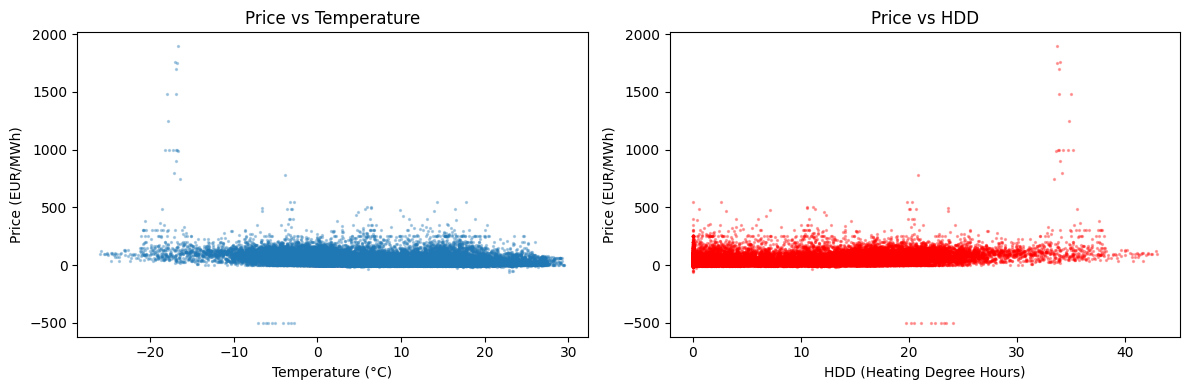

In [11]:
# plot price vs temperature to see the relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['temp'], df['price'], s=2, alpha=0.3)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Price vs Temperature')

axes[1].scatter(df['HDD'], df['price'], s=2, alpha=0.3, color='red')
axes[1].set_xlabel('HDD (Heating Degree Hours)')
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].set_title('Price vs HDD')
plt.tight_layout()
plt.show()

## 10. Data visualization

<Axes: >

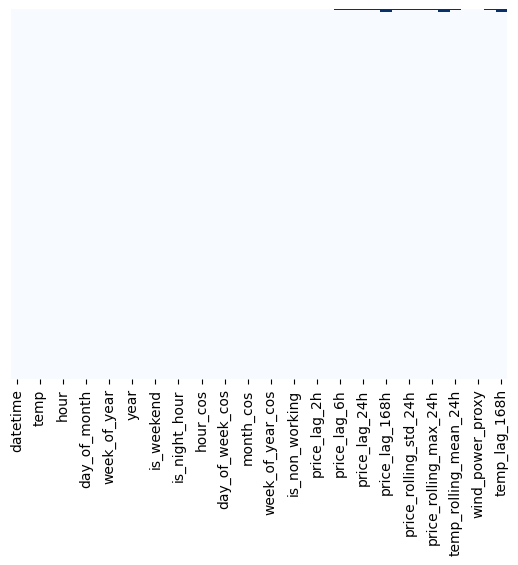

In [7]:
# check for missing values using a heatmap
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'Blues')

array([[<Axes: title={'center': 'datetime'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'wind_speed'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'day_of_month'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'week_of_year'}>,
        <Axes: title={'center': 'quarter'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'is_weekend'}>,
        <Axes: title={'center': 'is_peak_hour'}>],
       [<Axes: title={'center': 'is_night_hour'}>,
        <Axes: title={'center': 'hour_sin'}>,
        <Axes: title={'center': 'hour_cos'}>,
        <Axes: title={'center': 'day_of_week_sin'}>,
        <Axes: title={'center': 'day_of_week_cos'}>,
        <Axes: title={'center': 'month_sin'}>,
        <Axes: title={'center': 'month_cos'}>],
       [<Axe

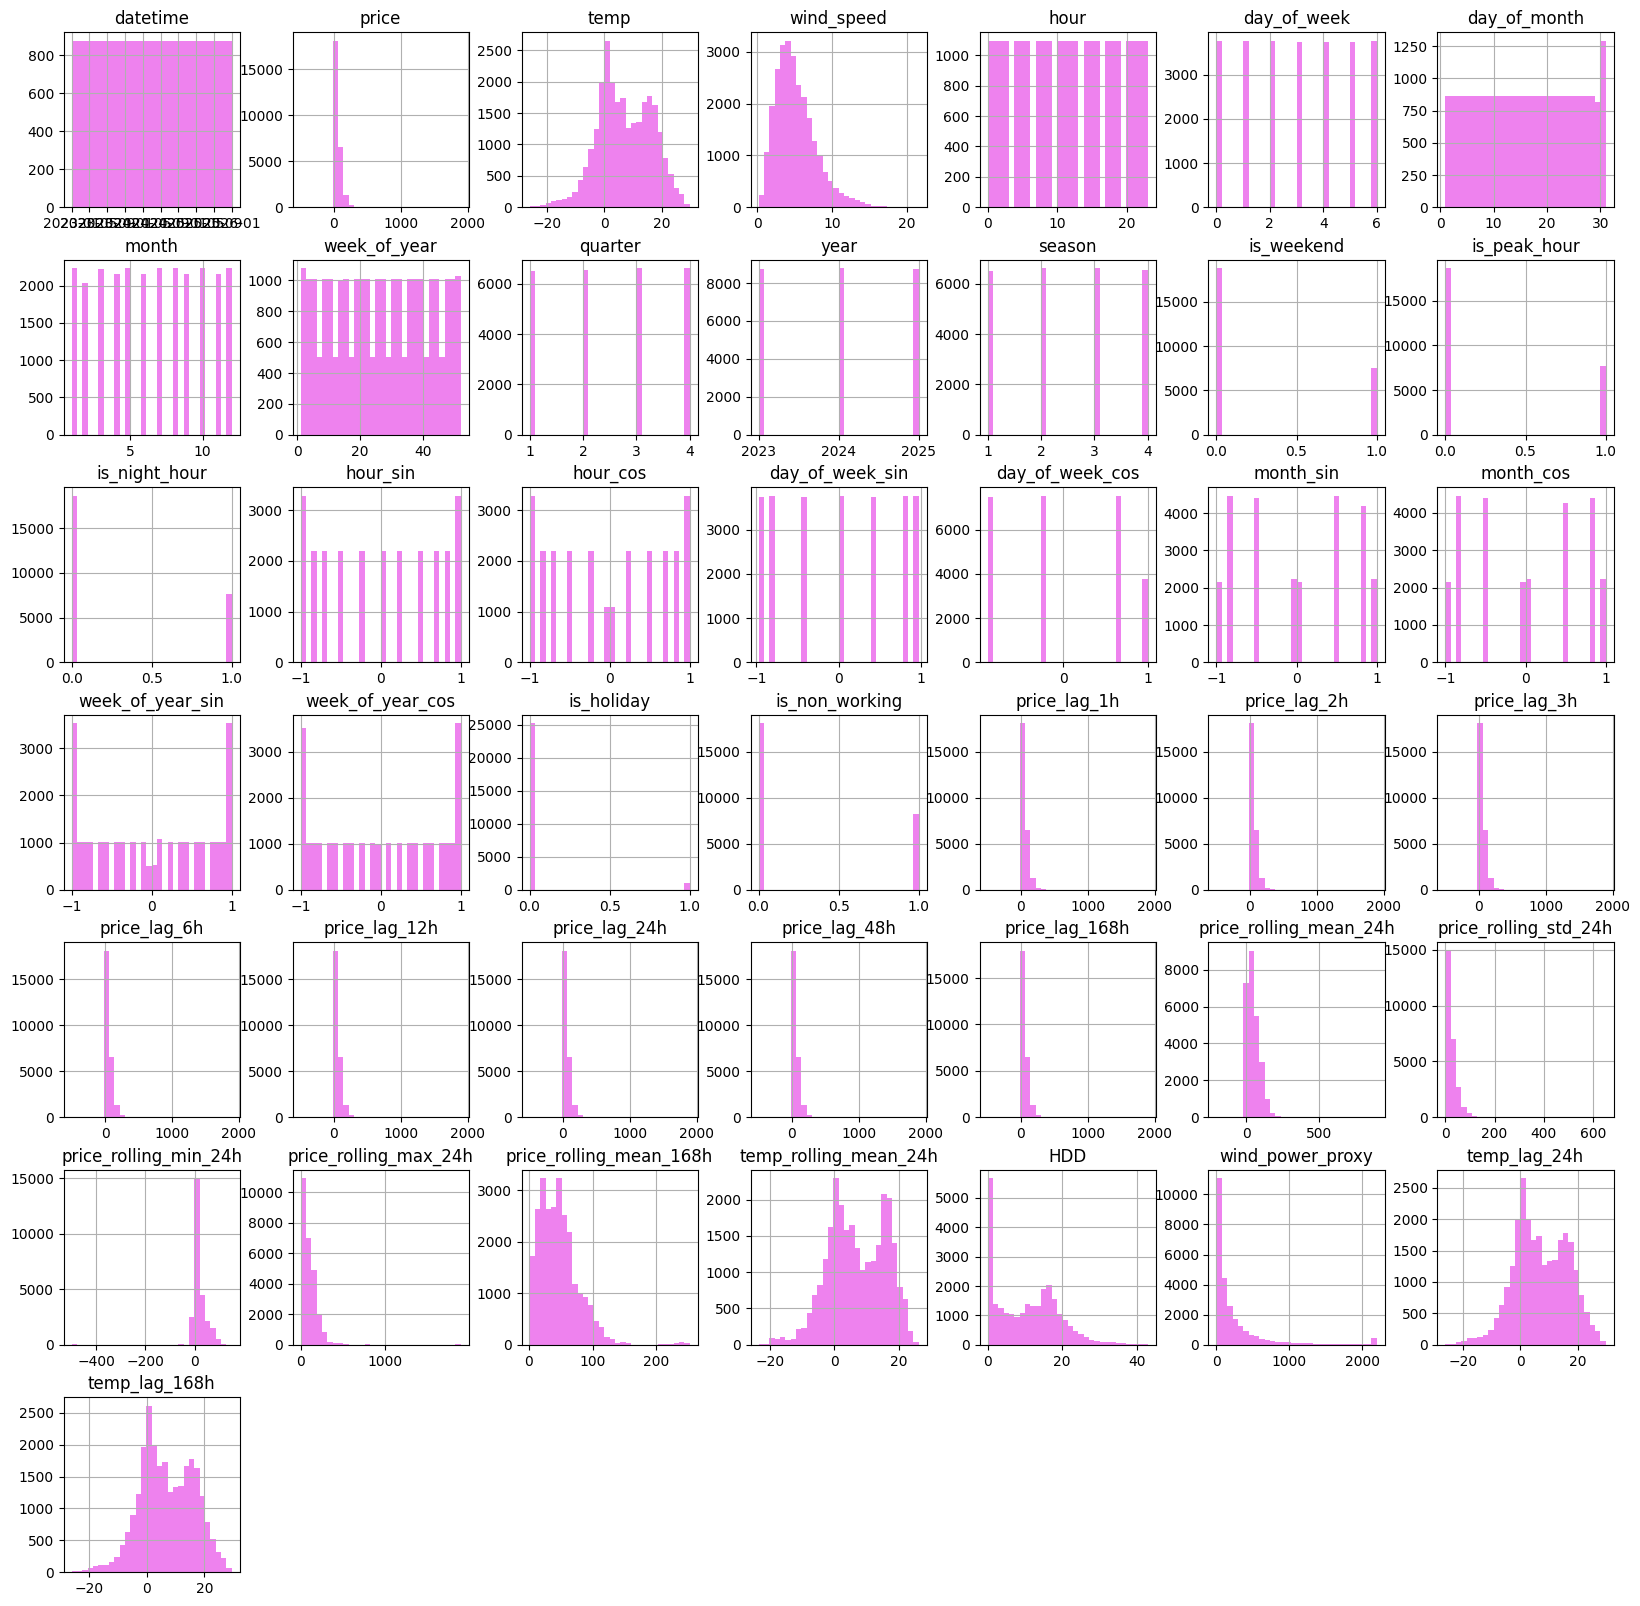

In [8]:
#plot histograms for all numeric columns to check their distributions
df.hist(bins = 30, figsize = (20,20),color = 'violet')

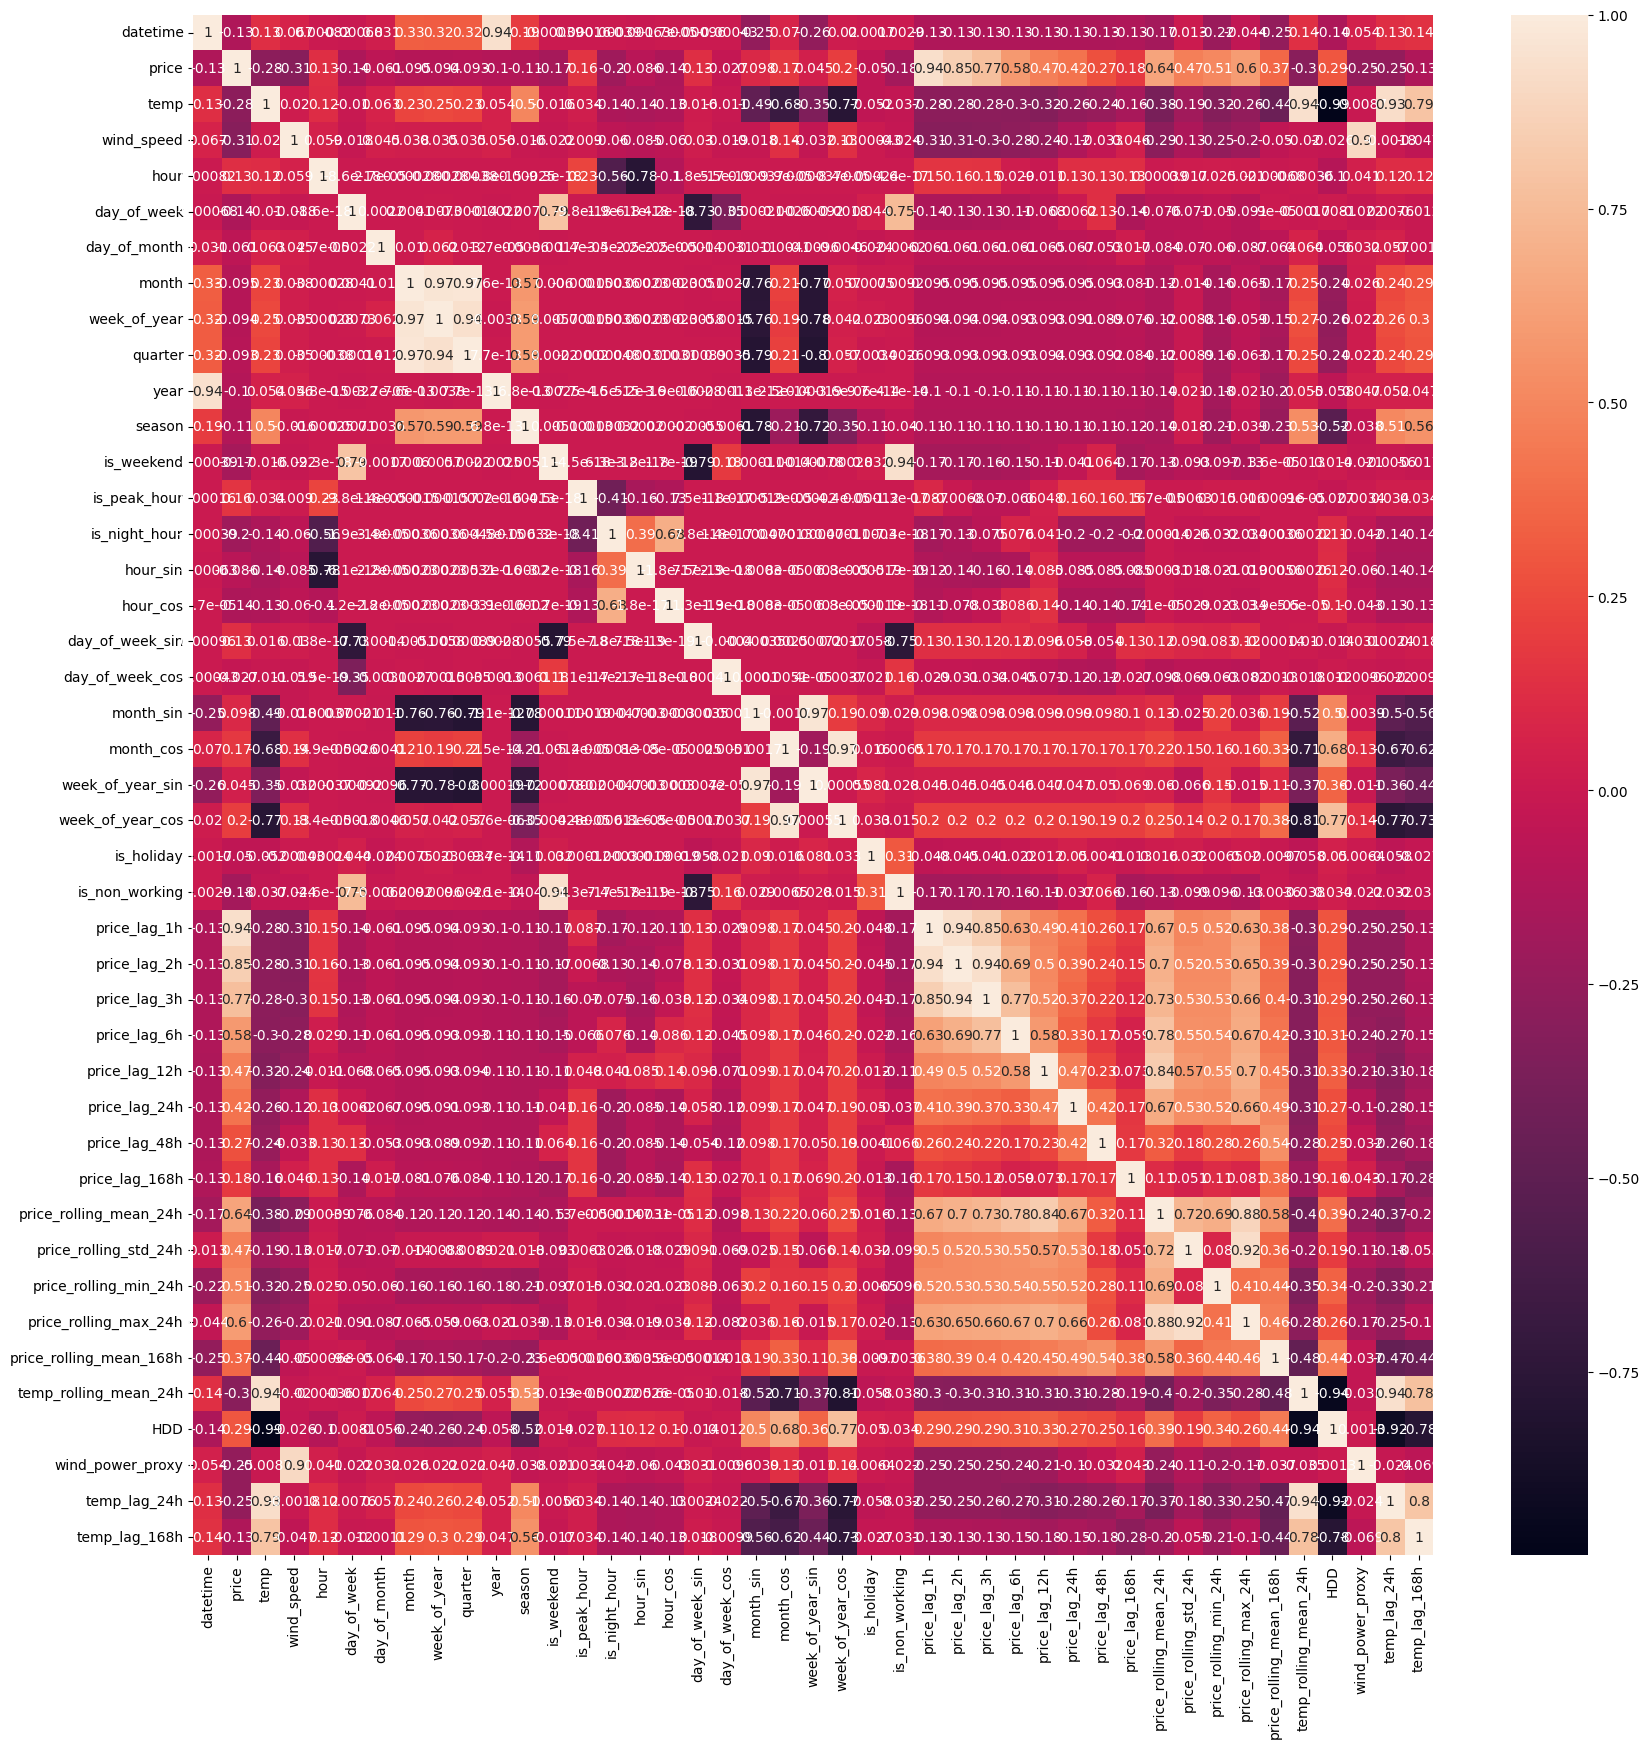

In [9]:
#plot the correlation matrix to check for correlations between the features and the target variable
plt.figure(figsize = (20,20))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()

## 11. How This CSV Feeds Into Model V2

1. `finland_electricity_features_v2.csv` is loaded by `../models/modelV2.ipynb`.
2. The target column is `price` (what we predict).
3. The feature columns are all other columns except `datetime` and `price`.
4. The model uses an 80/20 chronological split (no shuffle) to avoid data leakage.
5. XGBoost learns from all 40 features to predict future electricity prices.

This is a big improvement over V1, which only used `temp` and `wind_speed`.